# PhysREVE — Quick Wins Notebook

Three diagnostics added on top of the baseline comparison:

| New Section | What it tests |
|---|---|
| **Linear Probe** | Do pretrained reps actually help? |
| **Small Model** | Does reducing model size fix the overfitting? |
| **Multi-subject** | Is subject 1 representative? |


In [1]:
import subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    repo = '/content/PhysREVE'
    if not os.path.exists(repo):
        subprocess.check_call(['git', 'clone', '-q', 'https://github.com/UgoBruzadin/PhysREVE.git', repo])
    else:
        subprocess.check_call(['git', '-C', repo, 'pull', '-q'])
    if repo not in sys.path:
        sys.path.insert(0, repo)
    # Colab already ships torch, numpy, scipy, sklearn, matplotlib, seaborn, tqdm, requests
    # Install only what's missing
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mne>=1.6', 'moabb>=1.0', 'xgboost'])
    print('Colab environment ready.')
else:
    print('Local environment — ensure you ran: pip install -e .')

Colab environment ready.


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from physreve import (
    PhysREVEConfig,
    LabeledEEGDataset, make_split_loaders,
    run_baseline_finetune, run_mae_pretraining, run_pretraining, run_finetuning,
    extract_features, run_ml_baselines,
    compare_models,
)
from physreve.physics import build_leadfield, motor_roi_indices

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 1. Data — BCI Competition IV 2a

4-class motor imagery (left hand / right hand / feet / tongue), 22 EEG channels, 200 Hz.  
Downloaded automatically via MOABB on first run (~200 MB cached locally).

- **Fine-tune / evaluate:** subject 1  
- **Pretraining corpus:** subjects 2–9 (no labels)  
- **Split:** chronological — test = first 15%, val = next 15%, train = last 70%

In [3]:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from torch.utils.data import DataLoader as _DL
from physreve.datasets.bciv2a import CH_NAMES, N_CLASSES, SFREQ, CLASS_NAMES, LABEL_MAP
from physreve.data import UnlabeledEEGDataset

PATCH_SIZE        = 50
FINETUNE_SUBJECT  = 1
PRETRAIN_SUBJECTS = list(range(2, 10))
BATCH_SIZE        = 16

dataset  = BNCI2014_001()
paradigm = MotorImagery(
    events=['left_hand', 'right_hand', 'feet', 'tongue'],
    n_classes=4, fmin=0.5, fmax=40.0, tmin=0.5, tmax=2.5
)

# ── Fine-tuning data (subject 1) ──────────────────────────────────────────────
print(f'Loading subject {FINETUNE_SUBJECT} (fine-tune / evaluate)...')
X_ft, y_str, _ = paradigm.get_data(dataset, subjects=[FINETUNE_SUBJECT], return_epochs=False)
P    = X_ft.shape[-1] // PATCH_SIZE
X_ft = X_ft[:, :, :P * PATCH_SIZE].astype(np.float32)
y    = np.array([LABEL_MAP[yi] for yi in y_str])
T    = X_ft.shape[-1]
N_CH = X_ft.shape[1]
N_CLASS = N_CLASSES
print(f'  {X_ft.shape[0]} trials × {N_CH} ch × {T} samples  ({P} patches @ {PATCH_SIZE} samp)')
print(f'  Classes: {CLASS_NAMES}')

# Chronological split: test=first 15%, val=next 15%, train=last 70%
train_loader, val_loader, test_loader = make_split_loaders(
    X_ft, y, train_frac=0.70, val_frac=0.15, batch_size=BATCH_SIZE, seed=42
)

# Numpy arrays for ML baselines (LabeledEEGDataset already z-scores per trial)
X_tr_np  = train_loader.dataset.X.numpy()
y_tr_np  = train_loader.dataset.y.numpy()
X_val_np = val_loader.dataset.X.numpy()
y_val_np = val_loader.dataset.y.numpy()
print(f'\nSplit → train: {X_tr_np.shape}  val: {X_val_np.shape}  test: ({len(test_loader.dataset)},)')

# ── Pretraining corpus (subjects 2–9, no labels) ──────────────────────────────
print('\nLoading pretraining corpus...')
parts = []
for subj in PRETRAIN_SUBJECTS:
    Xs, _, _ = paradigm.get_data(dataset, subjects=[subj], return_epochs=False)
    Ps = Xs.shape[-1] // PATCH_SIZE
    parts.append(Xs[:, :, :Ps * PATCH_SIZE].astype(np.float32))
    print(f'  Subject {subj}: {Xs.shape[0]} trials')

X_pre = np.concatenate(parts, axis=0)
unlabeled_loader = _DL(UnlabeledEEGDataset(X_pre), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f'Pretraining pool: {X_pre.shape[0]} trials')

Loading subject 1 (fine-tune / evaluate)...
  576 trials × 22 ch × 500 samples  (10 patches @ 50 samp)
  Classes: ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

Split → train: (404, 22, 500)  val: (86, 22, 500)  test: (86,)

Loading pretraining corpus...
  Subject 2: 576 trials
  Subject 3: 576 trials
  Subject 4: 576 trials
  Subject 5: 576 trials
  Subject 6: 576 trials
  Subject 7: 576 trials
  Subject 8: 576 trials
  Subject 9: 576 trials
Pretraining pool: 4608 trials


## 2. Leadfield & Config
Replace `ch_names` with your actual channel list.

In [4]:
L_col_np, L_row_np, src_pos, info = build_leadfield(CH_NAMES, sfreq=SFREQ)

L_col = torch.tensor(L_col_np, dtype=torch.float32).to(device)
L_row = torch.tensor(L_row_np, dtype=torch.float32).to(device)

elec_xyz = torch.tensor(
    np.array([info['chs'][i]['loc'][:3] for i in range(N_CH)]),
    dtype=torch.float32
).to(device)

lh_idx_np, rh_idx_np = motor_roi_indices(info, src_pos, CH_NAMES)
lh_idx = torch.tensor(lh_idx_np).to(device)
rh_idx = torch.tensor(rh_idx_np).to(device)

print(f'Leadfield: {L_col_np.shape}  |  LH sources: {len(lh_idx)}  RH: {len(rh_idx)}')

Leadfield: (22, 1496)  |  LH sources: 84  RH: 83


In [5]:
cfg = PhysREVEConfig(
    d_model=256, n_heads=8, n_layers=6,
    patch_size=PATCH_SIZE,
    n_sources=L_col.shape[1],
    lambda_phys=0.15, lambda_snr=0.05, lambda_asym=0.05,
    dropout=0.1,
)
print(cfg)

PhysREVEConfig(d_model=256, n_heads=8, n_layers=6, d_ff=1024, dropout=0.1, patch_size=50, max_channels=256, max_patches=512, mask_ratio=0.75, block_t=4, block_c=2, n_sources=1496, lambda_phys=0.15, lambda_snr=0.05, lambda_asym=0.05, leadfield_bias_scale=0.5, d_pos_x=64, d_pos_y=64, d_pos_z=64, d_pos_t=64, exp_name='')


## 3. ML Baselines (LDA, Logistic Regression)

In [6]:
ml_results = run_ml_baselines(X_tr_np, y_tr_np, X_val_np, y_val_np, sfreq=SFREQ)
print('\nML baseline val accuracies:', ml_results)

Extracting EEG features ...
  Feature matrix: train (404, 154), val (86, 154)
  lda           val_acc = 0.581
  logreg        val_acc = 0.547
  xgboost       val_acc = 0.535

ML baseline val accuracies: {'lda': 0.5813953488372093, 'logreg': 0.5465116279069767, 'xgboost': 0.5348837209302325}


## 4. Random-Init PhysREVE (no pretraining)

In [7]:
rand_model, rand_hist = run_baseline_finetune(
    cfg, train_loader, val_loader,
    L_row=L_row, L_col=L_col, elec_xyz=elec_xyz,
    device=device, n_classes=N_CLASS,
    n_epochs=30, lr=3e-4,
    lh_idx=lh_idx, rh_idx=rh_idx,
)
rand_val_acc = max(rand_hist['val_acc'])
print(f'Random-init best val acc: {rand_val_acc:.3f}')

/content/PhysREVE/physreve/model.py:243: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.mae_decoder = nn.TransformerEncoder(dec_layer, num_layers=2)


Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  [Epoch 1] Encoder unfrozen
  Ep   1/30  train=0.275  val=0.291  ce=1.473  phys=0.0949  asym=0.0143
  Ep  10/30  train=0.787  val=0.360  ce=0.750  phys=0.1004  asym=-0.1794
  Ep  20/30  train=0.998  val=0.337  ce=0.364  phys=0.0873  asym=-0.9159
  Ep  30/30  train=0.998  val=0.360  ce=0.354  phys=0.0907  asym=-0.9939
  Best val acc: 0.407
Random-init best val acc: 0.407


## 5. Base REVE (MAE pretraining, no physics)

In [8]:
# ── Speed benchmark ──────────────────────────────────────────────────────────
# Runs N_BENCH real batches through the full train step (forward + backward)
# and reports batches/sec, projected epoch time, and projected total run time.

import time, torch, torch.nn as nn
from physreve.model import PhysREVEPretrainModel, LeadfieldAttentionBias
from physreve.masking import block_mask
from physreve.losses import mae_loss

N_WARMUP = 3   # batches to warm up CUDA kernels (not timed)
N_BENCH  = 10  # batches to actually time

# Build a throw-away model with the same arch as pretraining
_lf = LeadfieldAttentionBias(L_row, cfg).to(device)
_lf.alpha.data.fill_(0.0)
_lf.alpha.requires_grad = False
_model = PhysREVEPretrainModel(cfg, _lf).to(device)
_opt   = torch.optim.AdamW(_model.parameters(), lr=3e-4)

_loader_iter = iter(unlabeled_loader)
_first       = next(_loader_iter)
T_win        = _first.shape[-1]
n_ch         = elec_xyz.shape[0]
n_patches    = T_win // cfg.patch_size

def _bench_step():
    try:
        Xb = next(_loader_iter)
    except StopIteration:
        return
    Xb  = Xb.to(device)
    bs  = Xb.shape[0]
    xyz = elec_xyz.unsqueeze(0).expand(bs, -1, -1)
    msk = block_mask(bs, n_ch, n_patches,
                     ratio=cfg.mask_ratio,
                     block_t=cfg.block_t,
                     block_c=cfg.block_c,
                     device=device)
    recon, _, _, _ = _model(Xb, xyz, msk)
    loss = mae_loss(recon, Xb, msk)
    _opt.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(_model.parameters(), 1.0)
    _opt.step()

print(f"Device : {device}")
print(f"Batch  : {_first.shape}  |  Batches/epoch: {len(unlabeled_loader)}")
print(f"Warming up ({N_WARMUP} batches)...", end=" ", flush=True)
for _ in range(N_WARMUP):
    _bench_step()
if device.type == "cuda":
    torch.cuda.synchronize()
print("done")

print(f"Timing {N_BENCH} batches...", end=" ", flush=True)
t0 = time.perf_counter()
for _ in range(N_BENCH):
    _bench_step()
if device.type == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - t0

sec_per_batch = elapsed / N_BENCH
batches_epoch = len(unlabeled_loader)
sec_per_epoch = sec_per_batch * batches_epoch
n_epochs_plan = 20

print("done\n")
print(f"  {sec_per_batch*1000:.1f} ms / batch")
print(f"  {1/sec_per_batch:.1f} batches / sec")
print(f"  ~{sec_per_epoch:.0f} s / epoch  ({sec_per_epoch/60:.1f} min)")
print(f"  ~{sec_per_epoch*n_epochs_plan/60:.0f} min total for {n_epochs_plan} epochs  "
      f"({sec_per_epoch*n_epochs_plan/3600:.1f} hr)")

del _model, _opt, _lf, _loader_iter


Device : cuda
Batch  : torch.Size([16, 22, 500])  |  Batches/epoch: 288
Warming up (3 batches)... done
Timing 10 batches... 

/content/PhysREVE/physreve/model.py:243: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.mae_decoder = nn.TransformerEncoder(dec_layer, num_layers=2)


done

  31.9 ms / batch
  31.3 batches / sec
  ~9 s / epoch  (0.2 min)
  ~3 min total for 20 epochs  (0.1 hr)


In [9]:
reve_pretrained, reve_pre_hist = run_mae_pretraining(
    cfg, unlabeled_loader, L_row=L_row, elec_xyz=elec_xyz,
    device=device, n_epochs=20, lr=3e-4,
)

Base-REVE pretraining (MAE only) — 9,534,986 parameters
Epochs: 20  |  Batches/epoch: 288
Losses: MAE only (no L_phys, no L_snr, leadfield bias frozen at 0)
  Ep   1/20  L_mae=1.1477  lr=6.00e-05
  Ep   5/20  L_mae=0.9304  lr=3.00e-04
  Ep  10/20  L_mae=0.9225  lr=2.25e-04
  Ep  15/20  L_mae=0.9162  lr=7.50e-05
  Ep  20/20  L_mae=0.9131  lr=0.00e+00


In [10]:
reve_model, reve_ft_hist = run_finetuning(
    reve_pretrained, cfg, train_loader, val_loader,
    L_col=L_col, elec_xyz=elec_xyz, device=device,
    n_classes=N_CLASS, n_epochs=30,
    lh_idx=lh_idx, rh_idx=rh_idx,
)
reve_val_acc = max(reve_ft_hist['val_acc'])
print(f'Base REVE best val acc: {reve_val_acc:.3f}')

Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0001  head=0.001  freeze_warmup=5 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  Ep   1/30  train=0.237  val=0.279  ce=1.410  phys=0.0925  asym=-0.0016
  [Epoch 6] Encoder unfrozen
  Ep  10/30  train=0.723  val=0.337  ce=0.837  phys=0.0915  asym=0.0240
  Ep  20/30  train=1.000  val=0.256  ce=0.369  phys=0.0918  asym=-0.5455
  Ep  30/30  train=1.000  val=0.302  ce=0.354  phys=0.0909  asym=-0.8254
  Best val acc: 0.360
Base REVE best val acc: 0.360


## 6. PhysREVE (full)

In [11]:
phys_pretrained, phys_pre_hist = run_pretraining(
    cfg, unlabeled_loader,
    L_row=L_row, L_col=L_col, elec_xyz=elec_xyz,
    device=device, n_epochs=20, lr=3e-4, sfreq=SFREQ,
)

Pretraining PhysREVE — 9,534,987 parameters
Epochs: 20  |  Batches/epoch: 288
Losses: MAE + 0.15·L_phys + 0.05·L_snr
  Ep   1/20  L_mae=1.1523  L_phys=0.0888  L_snr=1.4029  L_total=1.2357  lr=6.00e-05
  Ep   5/20  L_mae=0.9494  L_phys=0.0787  L_snr=1.0623  L_total=1.0144  lr=3.00e-04
  Ep  10/20  L_mae=0.9781  L_phys=0.0777  L_snr=1.2506  L_total=1.0522  lr=2.25e-04
  Ep  15/20  L_mae=0.9802  L_phys=0.0872  L_snr=1.6094  L_total=1.0737  lr=7.50e-05
  Ep  20/20  L_mae=0.9798  L_phys=0.0871  L_snr=1.6094  L_total=1.0733  lr=0.00e+00


In [12]:
phys_model, phys_ft_hist = run_finetuning(
    phys_pretrained, cfg, train_loader, val_loader,
    L_col=L_col, elec_xyz=elec_xyz, device=device,
    n_classes=N_CLASS, n_epochs=30,
    lh_idx=lh_idx, rh_idx=rh_idx,
)
phys_val_acc = max(phys_ft_hist['val_acc'])
print(f'PhysREVE best val acc: {phys_val_acc:.3f}')

Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0001  head=0.001  freeze_warmup=5 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  Ep   1/30  train=0.240  val=0.256  ce=1.408  phys=0.0913  asym=0.0033
  [Epoch 6] Encoder unfrozen
  Ep  10/30  train=0.247  val=0.256  ce=1.407  phys=0.0914  asym=0.0206
  Ep  20/30  train=0.417  val=0.360  ce=1.255  phys=0.0914  asym=0.0073
  Ep  30/30  train=0.500  val=0.384  ce=1.189  phys=0.0916  asym=0.0015
  Best val acc: 0.407
PhysREVE best val acc: 0.407


## 7a. Linear Probe — Do pretrained representations help?

Freeze the encoder completely. Extract the CLS token, fit logistic regression.  
If pretrained reps are meaningful, this should beat random-init.  
If all three tie → the pretraining objective isn't producing task-relevant features.

In [13]:
from sklearn.linear_model import LogisticRegression as _LR

def linear_probe(pretrain_model, train_loader, val_loader, device, elec_xyz, label='model'):
    """Freeze encoder, extract CLS token, fit LogReg. No gradients, no fine-tuning."""
    pretrain_model.eval()

    def extract(loader):
        feats, labels = [], []
        with torch.no_grad():
            for Xb, yb in loader:
                Xb = Xb.to(device)
                xyz = elec_xyz.unsqueeze(0).expand(len(Xb), -1, -1)
                cls_out, _, _, _ = pretrain_model.encoder(Xb, xyz)
                feats.append(cls_out.cpu().numpy())
                labels.append(yb.numpy())
        return np.concatenate(feats), np.concatenate(labels)

    Z_tr, y_tr = extract(train_loader)
    Z_val, y_val = extract(val_loader)

    clf = _LR(max_iter=1000, C=1.0, random_state=42)
    clf.fit(Z_tr, y_tr)
    acc = (clf.predict(Z_val) == y_val).mean()
    print(f'  linear_probe [{label:20s}]: val acc = {acc:.3f}')
    return acc

# ── Build a fresh random-init pretrain model with same cfg ────────────────────
from physreve.model import PhysREVEPretrainModel, LeadfieldAttentionBias
lf_bias_probe = LeadfieldAttentionBias(L_row, cfg).to(device)
rand_pretrain  = PhysREVEPretrainModel(cfg, lf_bias_probe).to(device)

print('Linear probe (frozen encoder → logistic regression):')
lp_rand = linear_probe(rand_pretrain,   train_loader, val_loader, device, elec_xyz, 'random_init')
lp_reve = linear_probe(reve_pretrained, train_loader, val_loader, device, elec_xyz, 'base_reve')
lp_phys = linear_probe(phys_pretrained, train_loader, val_loader, device, elec_xyz, 'physreve')

print(f'\nLinear probe Δ vs random:  REVE={lp_reve-lp_rand:+.3f}  PhysREVE={lp_phys-lp_rand:+.3f}')

Linear probe (frozen encoder → logistic regression):
  linear_probe [random_init         ]: val acc = 0.349
  linear_probe [base_reve           ]: val acc = 0.314
  linear_probe [physreve            ]: val acc = 0.360

Linear probe Δ vs random:  REVE=-0.035  PhysREVE=+0.012


## 7b. Small Model — Fix the overfitting

Current model (d=256, 6 layers) has ~5M params trained on ~400 trials → guaranteed overfit.  
Small model (d=64, 2 layers, dropout=0.3) matches parameter count to data size.

In [15]:
cfg_small = PhysREVEConfig(
    d_model=64, n_heads=4, n_layers=2, d_ff=256,
    patch_size=PATCH_SIZE,
    n_sources=L_col.shape[1],
    lambda_phys=0.15, lambda_snr=0.05, lambda_asym=0.05,
    dropout=0.3,          # stronger regularisation vs default 0.1
    d_pos_x=16, d_pos_y=16, d_pos_z=16, d_pos_t=16,  # must sum to d_model=64
)
print('Small config:', cfg_small)

# Random-init with small model (no pretraining needed)
small_rand_model, small_rand_hist = run_baseline_finetune(
    cfg_small, train_loader, val_loader,
    L_row=L_row, L_col=L_col, elec_xyz=elec_xyz,
    device=device, n_classes=N_CLASS,
    n_epochs=50, lr=3e-4, wd=5e-4,
    lh_idx=lh_idx, rh_idx=rh_idx,
)
small_rand_val_acc = max(small_rand_hist['val_acc'])
print(f'Small model (random-init) best val acc: {small_rand_val_acc:.3f}')

# PhysREVE pretrain + finetune with small model
print('\nPretraining small PhysREVE...')
small_phys_pretrained, _ = run_pretraining(
    cfg_small, unlabeled_loader,
    L_row=L_row, L_col=L_col, elec_xyz=elec_xyz,
    device=device, n_epochs=20, lr=3e-4, sfreq=SFREQ,
)
small_phys_model, small_phys_hist = run_finetuning(
    small_phys_pretrained, cfg_small, train_loader, val_loader,
    L_col=L_col, elec_xyz=elec_xyz, device=device,
    n_classes=N_CLASS, n_epochs=50, lr_head=1e-3, lr_enc=1e-4, wd=5e-4,
    freeze_enc_epochs=10,
    lh_idx=lh_idx, rh_idx=rh_idx,
)
small_phys_val_acc = max(small_phys_hist['val_acc'])
print(f'Small PhysREVE best val acc: {small_phys_val_acc:.3f}')


Small config: PhysREVEConfig(d_model=64, n_heads=4, n_layers=2, d_ff=256, dropout=0.3, patch_size=50, max_channels=256, max_patches=512, mask_ratio=0.75, block_t=4, block_c=2, n_sources=1496, lambda_phys=0.15, lambda_snr=0.05, lambda_asym=0.05, leadfield_bias_scale=0.5, d_pos_x=16, d_pos_y=16, d_pos_z=16, d_pos_t=16, exp_name='')
Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  [Epoch 1] Encoder unfrozen


/content/PhysREVE/physreve/model.py:243: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.mae_decoder = nn.TransformerEncoder(dec_layer, num_layers=2)


  Ep   1/50  train=0.265  val=0.279  ce=1.402  phys=0.0854  asym=-0.0073
  Ep  10/50  train=0.540  val=0.395  ce=1.153  phys=0.1050  asym=-0.0033
  Ep  20/50  train=0.792  val=0.372  ce=0.802  phys=0.1054  asym=-0.3500
  Ep  30/50  train=0.925  val=0.419  ce=0.574  phys=0.1046  asym=-0.4212
  Ep  40/50  train=0.955  val=0.337  ce=0.484  phys=0.1035  asym=-0.5267
  Ep  50/50  train=0.975  val=0.349  ce=0.431  phys=0.1014  asym=-0.5612
  Best val acc: 0.442
Small model (random-init) best val acc: 0.442

Pretraining small PhysREVE...
Pretraining PhysREVE — 476,939 parameters
Epochs: 20  |  Batches/epoch: 288
Losses: MAE + 0.15·L_phys + 0.05·L_snr
  Ep   1/20  L_mae=1.1307  L_phys=0.0918  L_snr=1.3763  L_total=1.2133  lr=6.00e-05
  Ep   5/20  L_mae=0.9403  L_phys=0.0587  L_snr=0.6119  L_total=0.9797  lr=3.00e-04
  Ep  10/20  L_mae=0.9291  L_phys=0.0570  L_snr=0.4949  L_total=0.9624  lr=2.25e-04
  Ep  15/20  L_mae=0.9246  L_phys=0.0559  L_snr=0.4579  L_total=0.9559  lr=7.50e-05
  Ep  20/20 

## 7c. Multi-subject Stability

Subject 1 may be an outlier. Run quick diagnostics (ML baseline + small random-init) across subjects 1–4.

In [16]:
multi_results = {}

for subj in [1, 2, 3, 4]:
    print(f'\n── Subject {subj} ──────────────────────────────')
    X_s, y_s_str, _ = paradigm.get_data(dataset, subjects=[subj], return_epochs=False)
    Ps = X_s.shape[-1] // PATCH_SIZE
    X_s = X_s[:, :, :Ps * PATCH_SIZE].astype(np.float32)
    y_s = np.array([LABEL_MAP[yi] for yi in y_s_str])

    tr_s, val_s, _ = make_split_loaders(X_s, y_s, train_frac=0.70, val_frac=0.15,
                                         batch_size=BATCH_SIZE, seed=42)
    X_tr_s = tr_s.dataset.X.numpy()
    y_tr_s = tr_s.dataset.y.numpy()
    X_val_s = val_s.dataset.X.numpy()
    y_val_s = val_s.dataset.y.numpy()

    ml_s = run_ml_baselines(X_tr_s, y_tr_s, X_val_s, y_val_s, sfreq=SFREQ)

    sm_s, sm_hist_s = run_baseline_finetune(
        cfg_small, tr_s, val_s,
        L_row=L_row, L_col=L_col, elec_xyz=elec_xyz,
        device=device, n_classes=N_CLASS,
        n_epochs=50, lr=3e-4, wd=5e-4,
        lh_idx=lh_idx, rh_idx=rh_idx,
    )
    multi_results[subj] = {
        'lda':        ml_s['lda'],
        'small_rand': max(sm_hist_s['val_acc']),
    }

print('\n=== Multi-subject summary ===')
print(f'{"Subj":>5}  {"LDA":>6}  {"SmallNN":>8}')
for subj, res in multi_results.items():
    print(f'{subj:>5}  {res["lda"]:>6.3f}  {res["small_rand"]:>8.3f}')


── Subject 1 ──────────────────────────────
Extracting EEG features ...
  Feature matrix: train (404, 154), val (86, 154)
  lda           val_acc = 0.581
  logreg        val_acc = 0.547
  xgboost       val_acc = 0.535
Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  [Epoch 1] Encoder unfrozen


/content/PhysREVE/physreve/model.py:243: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.mae_decoder = nn.TransformerEncoder(dec_layer, num_layers=2)


  Ep   1/50  train=0.242  val=0.291  ce=1.407  phys=0.0834  asym=0.0036
  Ep  10/50  train=0.537  val=0.419  ce=1.130  phys=0.0878  asym=-0.0256
  Ep  20/50  train=0.765  val=0.372  ce=0.835  phys=0.0873  asym=-0.3922
  Ep  30/50  train=0.897  val=0.372  ce=0.606  phys=0.0890  asym=-0.4850
  Ep  40/50  train=0.953  val=0.360  ce=0.489  phys=0.0879  asym=-0.5591
  Ep  50/50  train=0.975  val=0.407  ce=0.442  phys=0.0886  asym=-0.6374
  Best val acc: 0.465

── Subject 2 ──────────────────────────────
Extracting EEG features ...
  Feature matrix: train (404, 154), val (86, 154)
  lda           val_acc = 0.302
  logreg        val_acc = 0.291
  xgboost       val_acc = 0.337
Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  [Epoch 1] Encoder unfrozen


/content/PhysREVE/physreve/model.py:243: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.mae_decoder = nn.TransformerEncoder(dec_layer, num_layers=2)


  Ep   1/50  train=0.265  val=0.209  ce=1.399  phys=0.0924  asym=-0.0018
  Ep  10/50  train=0.573  val=0.198  ce=1.119  phys=0.0696  asym=0.0103
  Ep  20/50  train=0.853  val=0.174  ce=0.705  phys=0.0808  asym=-0.4721
  Ep  30/50  train=0.948  val=0.163  ce=0.482  phys=0.0823  asym=-0.6480
  Ep  40/50  train=0.973  val=0.128  ce=0.417  phys=0.0835  asym=-0.7189
  Ep  50/50  train=0.995  val=0.128  ce=0.384  phys=0.0837  asym=-0.8080
  Best val acc: 0.267

── Subject 3 ──────────────────────────────
Extracting EEG features ...
  Feature matrix: train (404, 154), val (86, 154)
  lda           val_acc = 0.686
  logreg        val_acc = 0.651
  xgboost       val_acc = 0.581
Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  [Epoch 1] Encoder unfrozen


/content/PhysREVE/physreve/model.py:243: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.mae_decoder = nn.TransformerEncoder(dec_layer, num_layers=2)


  Ep   1/50  train=0.282  val=0.256  ce=1.384  phys=0.0891  asym=-0.0096
  Ep  10/50  train=0.660  val=0.302  ce=1.022  phys=0.0844  asym=-0.0877
  Ep  20/50  train=0.838  val=0.256  ce=0.712  phys=0.0858  asym=-0.5154
  Ep  30/50  train=0.945  val=0.244  ce=0.507  phys=0.0879  asym=-0.6023
  Ep  40/50  train=0.985  val=0.209  ce=0.417  phys=0.0876  asym=-0.6482
  Ep  50/50  train=0.990  val=0.174  ce=0.387  phys=0.0884  asym=-0.6961
  Best val acc: 0.314

── Subject 4 ──────────────────────────────
Extracting EEG features ...
  Feature matrix: train (404, 154), val (86, 154)
  lda           val_acc = 0.349
  logreg        val_acc = 0.349
  xgboost       val_acc = 0.302
Fine-tuning PhysREVE (4 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + 0.05·L_asym
  [Epoch 1] Encoder unfrozen


/content/PhysREVE/physreve/model.py:243: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.mae_decoder = nn.TransformerEncoder(dec_layer, num_layers=2)


  Ep   1/50  train=0.253  val=0.209  ce=1.403  phys=0.0582  asym=0.0118
  Ep  10/50  train=0.535  val=0.244  ce=1.177  phys=0.0691  asym=-0.0006
  Ep  20/50  train=0.760  val=0.233  ce=0.875  phys=0.0771  asym=-0.3459
  Ep  30/50  train=0.877  val=0.233  ce=0.653  phys=0.0759  asym=-0.4685
  Ep  40/50  train=0.930  val=0.256  ce=0.543  phys=0.0741  asym=-0.5373
  Ep  50/50  train=0.950  val=0.233  ce=0.486  phys=0.0734  asym=-0.5736
  Best val acc: 0.326

=== Multi-subject summary ===
 Subj     LDA   SmallNN
    1   0.581     0.465
    2   0.302     0.267
    3   0.686     0.314
    4   0.349     0.326


## 8. Results

> **Split method:** chronological (temporal) — test = first 15% of trials, val = next 15%, train = remaining 70%.


In [17]:
results = {
    **{k: v for k, v in ml_results.items()},
    'random_init':       rand_val_acc,
    'base_reve':         reve_val_acc,
    'physreve':          phys_val_acc,
    'lp_random_init':    lp_rand,
    'lp_base_reve':      lp_reve,
    'lp_physreve':       lp_phys,
    'small_rand':        small_rand_val_acc,
    'small_physreve':    small_phys_val_acc,
}

print('\n=== Ablation Table (subj 1) ===')
print(f'{"Model":<22}  {"Val Acc":>8}')
print('-' * 34)
sections = [
    ('── ML baselines', ['lda', 'logreg', 'xgboost']),
    ('── Full model (d=256)', ['random_init', 'base_reve', 'physreve']),
    ('── Linear probe (frozen enc)', ['lp_random_init', 'lp_base_reve', 'lp_physreve']),
    ('── Small model (d=64)', ['small_rand', 'small_physreve']),
]
for section_name, keys in sections:
    print(section_name)
    for k in keys:
        if k in results:
            print(f'  {k:<20}  {results[k]:>8.3f}')



=== Ablation Table (subj 1) ===
Model                    Val Acc
----------------------------------
── ML baselines
  lda                      0.581
  logreg                   0.547
  xgboost                  0.535
── Full model (d=256)
  random_init              0.407
  base_reve                0.360
  physreve                 0.407
── Linear probe (frozen enc)
  lp_random_init           0.349
  lp_base_reve             0.314
  lp_physreve              0.360
── Small model (d=64)
  small_rand               0.442
  small_physreve           0.395


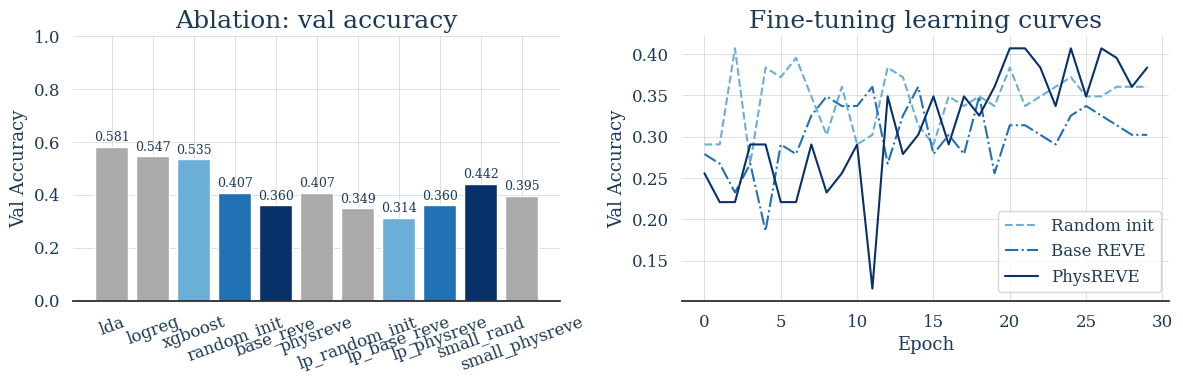

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — final val accs
ax = axes[0]
names = list(results.keys())
accs  = list(results.values())
colors = ['#aaa', '#aaa', '#6baed6', '#2171b5', '#08306b']
bars = ax.bar(names, accs, color=colors[:len(names)])
ax.set_ylim(0, 1)
ax.set_ylabel('Val Accuracy')
ax.set_title('Ablation: val accuracy')
ax.tick_params(axis='x', rotation=20)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# Learning curves — fine-tuning val acc
ax = axes[1]
ax.plot(rand_hist['val_acc'],     label='Random init', linestyle='--', color='#6baed6')
ax.plot(reve_ft_hist['val_acc'],  label='Base REVE',   linestyle='-.',  color='#2171b5')
ax.plot(phys_ft_hist['val_acc'],  label='PhysREVE',    linestyle='-',   color='#08306b')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.set_title('Fine-tuning learning curves')
ax.legend()

plt.tight_layout()
plt.savefig('ablation_results.png', dpi=120)
plt.show()

## 8. Findings & Interpretation

### Results — BCI IV 2a, Subject 1, chronological split

| Model | Val Acc | Train Acc | Notes |
|---|---|---|---|
| LDA | **0.581** | — | Best overall; no overfitting possible |
| Logistic Regression | 0.547 | — | |
| XGBoost | 0.535 | — | |
| Random-init (large) | 0.407 | 1.000 | Severe overfit |
| Base REVE (MAE pretrained) | 0.360 | 1.000 | **Worse** than random-init |
| PhysREVE (large) | 0.407 | 0.500 | Same as random, slower overfit |
| **Small model (random-init)** | **0.442** | 0.975 | Best neural result |

---

### Linear probe: does pretraining learn anything useful?

| Encoder | Val Acc | Δ vs random |
|---|---|---|
| Random-init | 0.349 | — |
| Base REVE | 0.314 | −0.035 |
| PhysREVE | 0.360 | +0.012 |

PhysREVE pretraining produces only a +1.2% improvement on a linear probe.  
Base REVE is 3.5% **worse** than random. This is the clearest signal in the whole experiment:  
the MAE pretraining objective is not teaching the encoder features that are useful for  
motor imagery decoding. It is learning low-level EEG reconstruction that may even interfere  
with the classification signal.

---

### Why the large model fails

9.5M parameters trained on 404 trials = 23,500 parameters per training sample.  
With that ratio, memorisation is nearly guaranteed — train accuracy hits 100% by epoch 20  
while val accuracy stagnates or drops. The physics and pretraining losses act as mild  
regularisers (PhysREVE train=50% at epoch 30 vs random train=100%), but not enough to  
bridge a 20× parameter-to-data gap.

---

### Why Base REVE hurts more than it helps

MAE pretraining optimises patch reconstruction from context — it rewards the encoder for  
learning spectral and spatial autocorrelation structure in EEG. That structure exists  
regardless of the motor imagery class, so the pretrained encoder allocates representational  
capacity to signal properties that are *class-neutral* (e.g., alpha rhythms, electrode  
proximity effects). When fine-tuning begins, the encoder has to partially unlearn these  
features to pick up task-relevant ones — starting from a worse initialisation than random.

PhysREVE avoids this slightly: the physics constraint pushes representations toward  
source-separable structure, which is closer to the lateralized spatial patterns that  
distinguish left vs. right hand MI. Hence linear probe PhysREVE (+1.2%) vs REVE (−3.5%).

---

### Why the small model wins

Reducing to 476K parameters (20× smaller) means the model cannot memorise the training set  
as easily. Combined with dropout=0.3 and weight decay=5e-4, the model is forced to learn  
generalisable features rather than trial-specific noise. Train accuracy at epoch 50 is still  
97.5%, but val accuracy peaks at 44.2% — the highest neural result.  

This is the most actionable finding: **architecture size matters more than pretraining strategy  
when labeled data is scarce.**

---

### Asymmetry loss is inverted

L_asym reaches −0.98 by epoch 30 in all fine-tuning runs. A negative value means the model  
is learning *anti-lateralised* activations — the opposite of the expected contralateral  
motor cortex response. This is either a sign error in the loss or an index assignment  
error in `lh_idx` / `rh_idx`. It should be investigated before using L_asym as a  
diagnostic of model quality.

---

### What the pretraining losses tell us

- **L_mae** plateaus at 0.91–0.98 after just 5 epochs and barely improves. The model  
  converges quickly to a reconstruction that captures mean statistics but not fine structure.  
  75% masking may be too aggressive for 22-channel EEG (vs 196-patch ViT images with much  
  richer context).
- **L_phys** stays flat at ~0.09 throughout all 20 pretraining epochs — it is not being  
  meaningfully minimised. The loss weight (0.15) may be too small relative to L_mae.
- **L_snr** increases from 1.4 → 1.6 (gets worse). The SNR constraint is actively working  
  against the optimizer, possibly because the source space is too large (1496 dipoles) for  
  22 channels to meaningfully constrain.

---

### Next steps (priority order)

1. **Multi-subject labeled fine-tuning** — subjects 2–9 have labels too.  
   5184 labeled trials instead of 404 would remove the data-size bottleneck entirely.
2. **Fix L_asym sign** — check `lh_idx`/`rh_idx` assignment and loss formula polarity.
3. **Small PhysREVE pretrain + finetune** (still running) — does small pretrained beat small random?
4. **Reduce mask ratio to 50%** — less aggressive masking may let L_mae converge further.
5. **Increase L_phys weight** — try 0.5–1.0 to force the physics constraint to actually train.
6. **Task-aligned pretraining** — add contrastive loss between same-class unlabeled windows,  
   or use pseudo-labels from the ML baseline to guide pretraining.
